In [1]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
from matplotlib import gridspec

In [2]:
def plot_rmse_heatmap_matrix(
    df_results,
    x_axis="SOC",
    y_axis="T",
    rmse_cols=["WLTC_rmse", "NEDC_rmse", "UDDS_rmse"],
    save_path=None,
    scale_factor=1000,
    cmap_colors=["green", "yellow", "red"],
    figsize=(20,14),
    vmin=None,
    vmax=None,
    profile_order=["UDDS", "NEDC", "WLTC", "impulse_72_s", "impulse_144_s", "impulse_288_s"]
):
    # Усреднение по остальным колонкам
    df_mean = df_results.groupby([x_axis, y_axis, "profile"], as_index=False)[rmse_cols].mean()

    x_values = sorted(df_mean[x_axis].unique())
    y_values = sorted(df_mean[y_axis].unique())
    
    profiles_present = [p for p in profile_order if p in df_mean["profile"].unique()]

    rmse_display_names = [name.replace("_rmse","") for name in rmse_cols]

    validation_tables = {}
    all_rmse = []

    for x_val in x_values:
        validation_tables[x_val] = {}
        for y_val in y_values:
            df_cell = df_mean[(df_mean[x_axis]==x_val)&(df_mean[y_axis]==y_val)]
            if df_cell.empty:
                continue
            M = df_cell.set_index("profile")[rmse_cols].T.reindex(index=rmse_cols, columns=profiles_present)
            M.index = rmse_display_names
            validation_tables[x_val][y_val] = M
            all_rmse.extend(M.values.flatten())

    cmap = LinearSegmentedColormap.from_list("custom_cmap", cmap_colors)
    if vmin is None: vmin = min(all_rmse)*scale_factor
    else: vmin *= scale_factor
    if vmax is None: vmax = max(all_rmse)*scale_factor
    else: vmax *= scale_factor

    fig = plt.figure(figsize=figsize)
    gs = gridspec.GridSpec(len(y_values), len(x_values), figure=fig, wspace=0.4, hspace=0.4)

    for i, y_val in enumerate(y_values):
        for j, x_val in enumerate(x_values):
            ax = fig.add_subplot(gs[i,j])
            if y_val not in validation_tables[x_val]:
                ax.axis("off")
                continue
            M = validation_tables[x_val][y_val]*scale_factor
            sns.heatmap(M, annot=True, fmt=".1f", cmap=cmap, vmin=vmin, vmax=vmax,
                        cbar=False, ax=ax, square=True, linewidths=0.5, linecolor="gray")
            ax.set_xlabel("")
            ax.set_ylabel("")

    for ax in fig.axes:
        if ax.get_xticklabels():
            ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=10)

    for ax in fig.axes:
        if ax.get_yticklabels():
            ax.set_yticklabels(ax.get_yticklabels(), rotation=45, fontsize=10)

    # Общий colorbar справа
    cbar_ax = fig.add_axes([0.92,0.1,0.015,0.78])
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin,vmax=vmax))
    sm.set_array([])
    cbar = fig.colorbar(sm,cax=cbar_ax)
    cbar.set_label("RMSE, mV", fontsize=16, rotation=270, labelpad=20)

    # Заголовки столбцов
    for j, x_val in enumerate(x_values):
        fig.axes[j].set_title(str(x_val), fontsize=16, pad=20)
    
    # Подписи строк
    for i, y_val in enumerate(y_values):
        ax = fig.axes[i*len(x_values)]
        ax.set_ylabel(f"{y_val}", fontsize=16, rotation=0, labelpad=60, va="center")

    fig.text(0.5, 0.95, x_axis, ha='center', va='top', fontsize=22, fontweight="bold")
    fig.text(0.02,0.5,"Validation RMSE", ha='right', va='center', rotation=90, fontsize=22, fontweight="bold")

    # if save_path:
    #     plt.savefig(save_path,dpi=300,bbox_inches="tight")
    # plt.show()


In [3]:
def plot_rmse_heatmap_profiles(
    df_results,
    y_axis="SOC",
    rmse_cols=["UDDS_rmse","NEDC_rmse","WLTC_rmse"],
    save_path=None,
    scale_factor=1000,
    cmap_colors=["green","yellow","red"],
    figsize=(14,10),
    profile_order=["UDDS","NEDC","WLTC","impulse_72_s","impulse_144_s","impulse_288_s"],
    ticklabel_fontsize=12,
    axislabel_fontsize=16,
    title_fontsize=18
):
    """
    Heatmap RMSE по профилям (ось X) и произвольной переменной (ось Y: SOC/SOH/T),
    усредненное по другим профилям валидации и другим параметрам,
    исключая RMSE совпадающего профиля.
    Цвета нормированы по всем данным.
    """
    
    y_values = sorted(df_results[y_axis].unique())
    profiles_present = [p for p in profile_order if p in df_results["profile"].unique()]
    rmse_display_names = [name.replace("_rmse","") for name in rmse_cols]

    # Собираем все значения RMSE (с исключением совпадений), чтобы потом вычислить глобальный vmin/vmax
    all_rmse_values = []

    # Создаем пустую матрицу
    heatmap_data = np.full((len(y_values), len(profiles_present)), np.nan)

    for i, y_val in enumerate(y_values):
        for j, profile_param in enumerate(profiles_present):
            df_subset = df_results[df_results[y_axis] == y_val]

            # Исключаем совпадающий профиль
            valid_rmse_cols = [
                col for col in rmse_cols
                if not col.startswith(profile_param)
            ]


            mean_rmse = df_subset[valid_rmse_cols].mean().mean()
            heatmap_data[i,j] = mean_rmse * scale_factor
            all_rmse_values.append(mean_rmse * scale_factor)

    # Глобальная нормировка
    vmin = np.nanmin(all_rmse_values)
    vmax = np.nanmax(all_rmse_values)

    cmap = LinearSegmentedColormap.from_list("custom_cmap", cmap_colors)

    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(
        heatmap_data,
        annot=True,
        fmt=".1f",
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        xticklabels=profiles_present,
        yticklabels=y_values,
        square=True,
        linewidths=0.5,
        linecolor="gray",
        ax=ax
    )

    ax.set_xlabel("Profile", fontsize=axislabel_fontsize)
    ax.set_ylabel(y_axis, fontsize=axislabel_fontsize)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=ticklabel_fontsize)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=ticklabel_fontsize)
    ax.set_title(f"Heatmap RMSE vs Profiles (excluding same profile)", fontsize=title_fontsize)

    # Colorbar
    cbar = ax.collections[0].colorbar
    cbar.set_label("RMSE, mV", fontsize=axislabel_fontsize)

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()


In [4]:
def plot_rmse_profile_histogram(
    df_results,
    rmse_cols,
    profile_order=None,
    scale_factor=1000,
    cmap_colors=("green", "yellow", "red"),
    figsize=(10, 6)
):
    """
    Гистограмма:
    X — профиль параметризации
    Y — средний RMSE (исключая валидацию на том же профиле)
    """

    profiles = (
        profile_order
        if profile_order is not None
        else sorted(df_results["profile"].unique())
    )

    profile_rmse_mean = {}

    for profile_param in profiles:
        df_p = df_results[df_results["profile"] == profile_param]

        if df_p.empty:
            continue

        # исключаем RMSE того же профиля
        valid_rmse_cols = [
            col for col in rmse_cols
            if not col.startswith(profile_param)
        ]

        if not valid_rmse_cols:
            continue

        rmse_values = df_p[valid_rmse_cols].values.flatten()
        rmse_values = rmse_values[~np.isnan(rmse_values)]

        if len(rmse_values) == 0:
            continue

        profile_rmse_mean[profile_param] = rmse_values.mean() * scale_factor

    # --- подготовка к рисованию ---
    labels = list(profile_rmse_mean.keys())
    values = list(profile_rmse_mean.values())

    cmap = LinearSegmentedColormap.from_list("GYR", cmap_colors)
    norm = plt.Normalize(min(values), max(values))
    colors = cmap(norm(values))

    # --- plot ---
    fig, ax = plt.subplots(figsize=figsize)

    bars = ax.bar(labels, values, color=colors, edgecolor="black")

    ax.set_ylabel("RMSE, mV", fontsize=14)
    ax.set_xlabel("Parameterization profile", fontsize=14)
    ax.set_title(
        "Mean validation RMSE\n(excluding same-profile validation)",
        fontsize=16,
        pad=15
    )

    ax.set_xticklabels(labels, rotation=45, ha="right")

    # подписи над столбцами
    for bar, val in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"{val:.1f}",
            ha="center",
            va="bottom",
            fontsize=11
        )

    # colorbar
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, pad=0.02)
    cbar.set_label("RMSE, mV", rotation=270, labelpad=15)

    plt.tight_layout()
    plt.show()


In [5]:
import numpy as np
import matplotlib.pyplot as plt


def plot_rmse_profile_with_spread(
    df_results,
    rmse_cols,
    profile_order=None,
    scale_factor=1000,
    figsize=(12, 6),
    color="tab:blue",
    alpha_fill=0.25
):
    """
    Линия среднего RMSE + тень min–max
    (исключая валидацию на том же профиле)
    """

    profiles = (
        profile_order
        if profile_order is not None
        else sorted(df_results["profile"].unique())
    )

    mean_vals = []
    min_vals = []
    max_vals = []
    valid_profiles = []

    for profile_param in profiles:
        df_p = df_results[df_results["profile"] == profile_param]

        if df_p.empty:
            continue

        # исключаем RMSE того же профиля
        valid_rmse_cols = [
            col for col in rmse_cols
            if not col.startswith(profile_param)
        ]

        if not valid_rmse_cols:
            continue

        rmse = df_p[valid_rmse_cols].values.flatten()
        rmse = rmse[~np.isnan(rmse)]

        if len(rmse) == 0:
            continue

        valid_profiles.append(profile_param)
        mean_vals.append(rmse.mean() * scale_factor)
        min_vals.append(rmse.min() * scale_factor)
        max_vals.append(rmse.max() * scale_factor)

    # --- plot ---
    x = np.arange(len(valid_profiles))

    fig, ax = plt.subplots(figsize=figsize)

    ax.plot(
        x,
        mean_vals,
        marker="o",
        linewidth=2,
        color=color,
        label="Mean RMSE"
    )

    ax.fill_between(
        x,
        min_vals,
        max_vals,
        color=color,
        alpha=alpha_fill,
        label="Min–Max RMSE"
    )

    ax.set_xticks(x)
    ax.set_xticklabels(valid_profiles, rotation=45, ha="right")

    ax.set_ylabel("RMSE, mV", fontsize=14)
    ax.set_xlabel("Parameterization profile", fontsize=14)
    ax.set_title(
        "Validation RMSE spread\n(excluding same-profile validation)",
        fontsize=16,
        pad=15
    )

    ax.grid(True, axis="y", alpha=0.3)
    ax.legend()

    plt.tight_layout()
    plt.show()


In [6]:
def data_visualization(U, U_sim, OCV, I, t, SOC):
    plt.figure(figsize=(10, 8))

    #  Voltage
    plt.subplot(4, 1, 1)
    plt.plot(t, U, label='measured', linewidth=1.2)
    plt.plot(t, OCV, label='OCV', linewidth=1.2)
    plt.plot(t, U_sim, '--', label='simulated', linewidth=1.2)
    plt.ylabel('Voltage, V')
    plt.legend()
    plt.grid(True, alpha=0.3)

    #  Current
    plt.subplot(4, 1, 2)
    plt.plot(t, I, label='current', linewidth=1.2)
    plt.ylabel('Current, A')
    plt.title('Current')
    plt.grid(True, alpha=0.3)

    #  SOC
    plt.subplot(4, 1, 3)
    plt.plot(t, SOC, label='SOC', color='purple', linewidth=1.2)
    plt.ylabel('SOC')
    plt.title('State of Charge')
    plt.grid(True, alpha=0.3)

    # Error
    err = U - U_sim
    plt.subplot(4, 1, 4)
    plt.plot(t, err, label='error', linewidth=1.2)
    plt.ylabel('Error, V')
    plt.xlabel('Time, s')
    plt.title(f'Error (mean abs = {np.mean(np.abs(err)):.4f} V)')
    plt.grid(True, alpha=0.3)

    plt.tight_layout()


In [7]:
def plot_rmse_spider(
    df_results,
    rmse_cols,
    profile_order,
    scale_factor=1000,
    normalize=True,
    figsize=(8, 8)
):
    """
    Spider diagram:
    - оси: валидационные профили
    - линии: профили параметризации
    """

    val_profiles = [c.replace("_rmse", "") for c in rmse_cols]
    n_axes = len(val_profiles)

    angles = np.linspace(0, 2*np.pi, n_axes, endpoint=False).tolist()
    angles += angles[:1]

    profile_rmse = {}
    all_rmse = []

    for profile_param in profile_order:
        df_p = df_results[df_results["profile"] == profile_param]
        if df_p.empty:
            continue

        values = []
        for col, vprof in zip(rmse_cols, val_profiles):
            if vprof == profile_param:
                values.append(np.nan)
            else:
                rmse = df_p[col].dropna().values
                values.append(rmse.mean() * scale_factor)
                all_rmse.extend(rmse * scale_factor)

        profile_rmse[profile_param] = values

    max_rmse = max(all_rmse)

    fig, ax = plt.subplots(figsize=figsize, subplot_kw=dict(polar=True))

    for profile, vals in profile_rmse.items():
        vals = np.array(vals)
        if normalize:
            vals = vals / max_rmse
        vals = np.nan_to_num(vals, nan=0.0)
        vals = np.append(vals, vals[0])

        ax.plot(angles, vals, linewidth=2, label=profile)
        ax.fill(angles, vals, alpha=0.1)

    ax.set_thetagrids(np.degrees(angles[:-1]), val_profiles)
    ax.set_rlabel_position(0)

    if normalize:
        ax.set_ylim(0, 1)
        ax.set_ylabel("Normalized RMSE", labelpad=20)
    else:
        ax.set_ylabel("RMSE, mV", labelpad=20)

    ax.set_title(
        "Validation RMSE spider diagram\n(excluding self-validation)",
        fontsize=14,
        pad=20
    )

    ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
    plt.tight_layout()
    plt.show()


In [8]:
current_dir = Path.cwd()

validation_results = current_dir.parent / "validation" / "validation_results.csv"

df_results = pd.read_csv(validation_results)

In [9]:
df_results

,profile,Battery_ID,SOH,T,SOC,Q_Ah,eta,OCV_file_name,R0,R,tau,UDDS_rmse,NEDC_rmse,WLTC_rmse
0,NEDC,1,94,25,55-35,3.289069,0.993163,OCV_1_+25.csv,0.040102,[ 0.18500965 -0.15799339],[74.79622419 74.46096847],0.001607,0.001041,0.003730
1,NEDC,1,94,25,75-55,3.289069,0.993163,OCV_1_+25.csv,0.043565,[ 2.38419122 -2.33588565],[76.6982802 75.91917751],0.003704,0.004663,0.009395
2,NEDC,1,94,25,95-75,3.289069,0.993163,OCV_1_+25.csv,0.044178,[-3.1062521 3.13802852],[76.12695194 76.00372429],0.005518,0.006065,0.006392
3,UDDS,1,94,25,55-35,3.289069,0.993163,OCV_1_+25.csv,0.038852,[ 0.05812656 -0.0271138 ],[70.43697862 64.5548939 ],0.001246,0.001514,0.002797
4,UDDS,1,94,25,75-55,3.289069,0.993163,OCV_1_+25.csv,0.040251,[ 0.14614713 -0.09671487],[70.3419654 63.7584806],0.003512,0.004939,0.010060
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
265,impulse_288_s,5,98,35,75-55,3.434987,0.991690,OCV_5_+35.csv,0.041669,[ 0.11122546 -0.09116178],[63.50124231 51.079858 ],0.005389,0.006749,0.012505
266,impulse_288_s,5,98,35,95-75,3.434987,0.991690,OCV_5_+35.csv,0.037150,[ 0.04318691 -0.02255343],[60.161704 49.73728641],0.004207,0.005162,0.006004
267,impulse_72_s,5,98,35,55-35,3.434987,0.991690,OCV_5_+35.csv,0.037404,[ 0.0295919 -0.01634364],[23.43636714 5.62030503],0.004317,0.003572,0.006101
268,impulse_72_s,5,98,35,75-55,3.434987,0.991690,OCV_5_+35.csv,0.038704,[ 0.0609155 -0.0486512],[15.63131377 6.06766978],0.009007,0.010351,0.017256


In [10]:
rmse_cols = ["UDDS_rmse", "NEDC_rmse", "WLTC_rmse"]
all_rmse = df_results[rmse_cols].values.flatten()
vmin_global = all_rmse.min()
vmax_global = all_rmse.max()

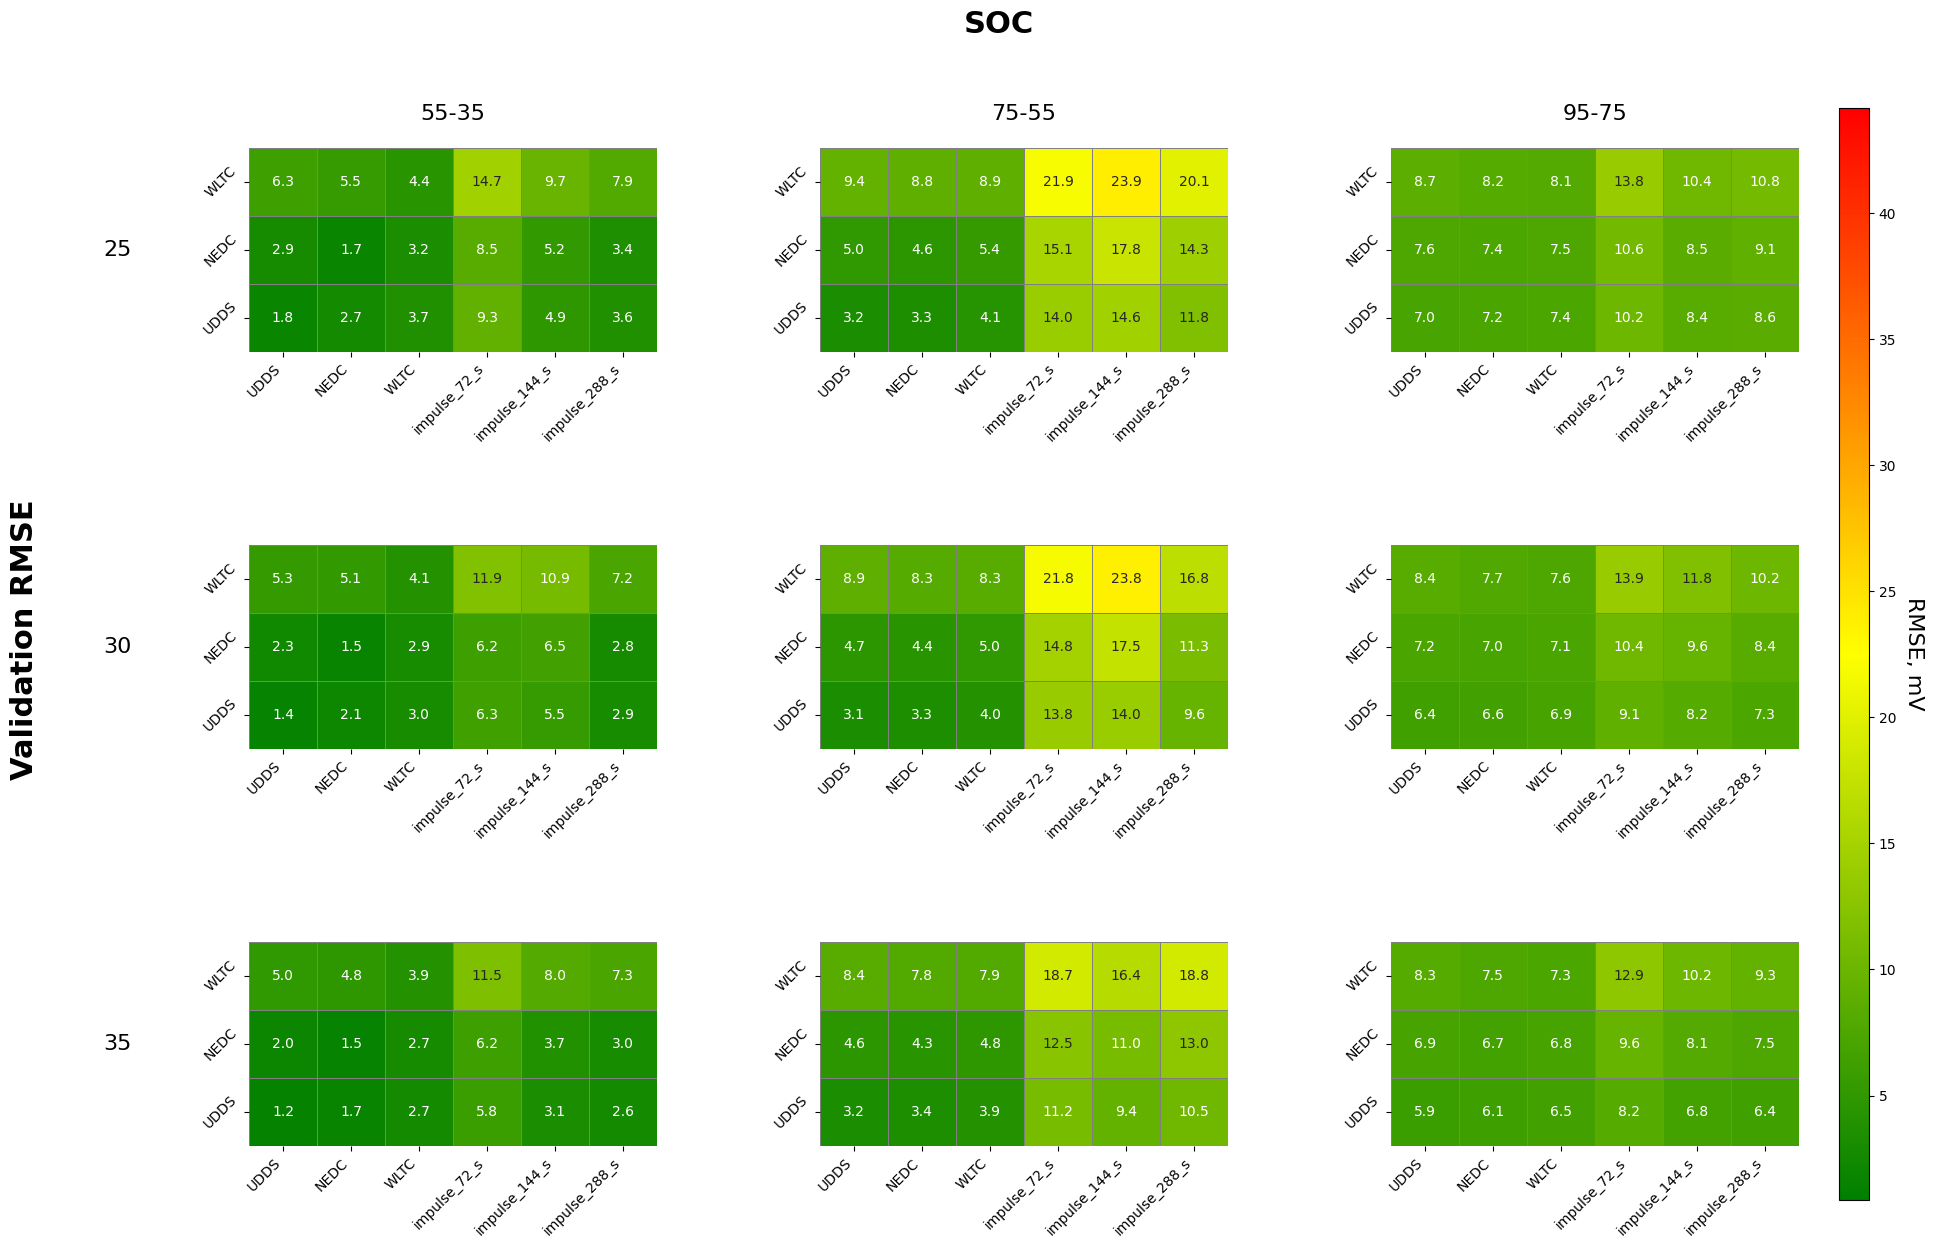

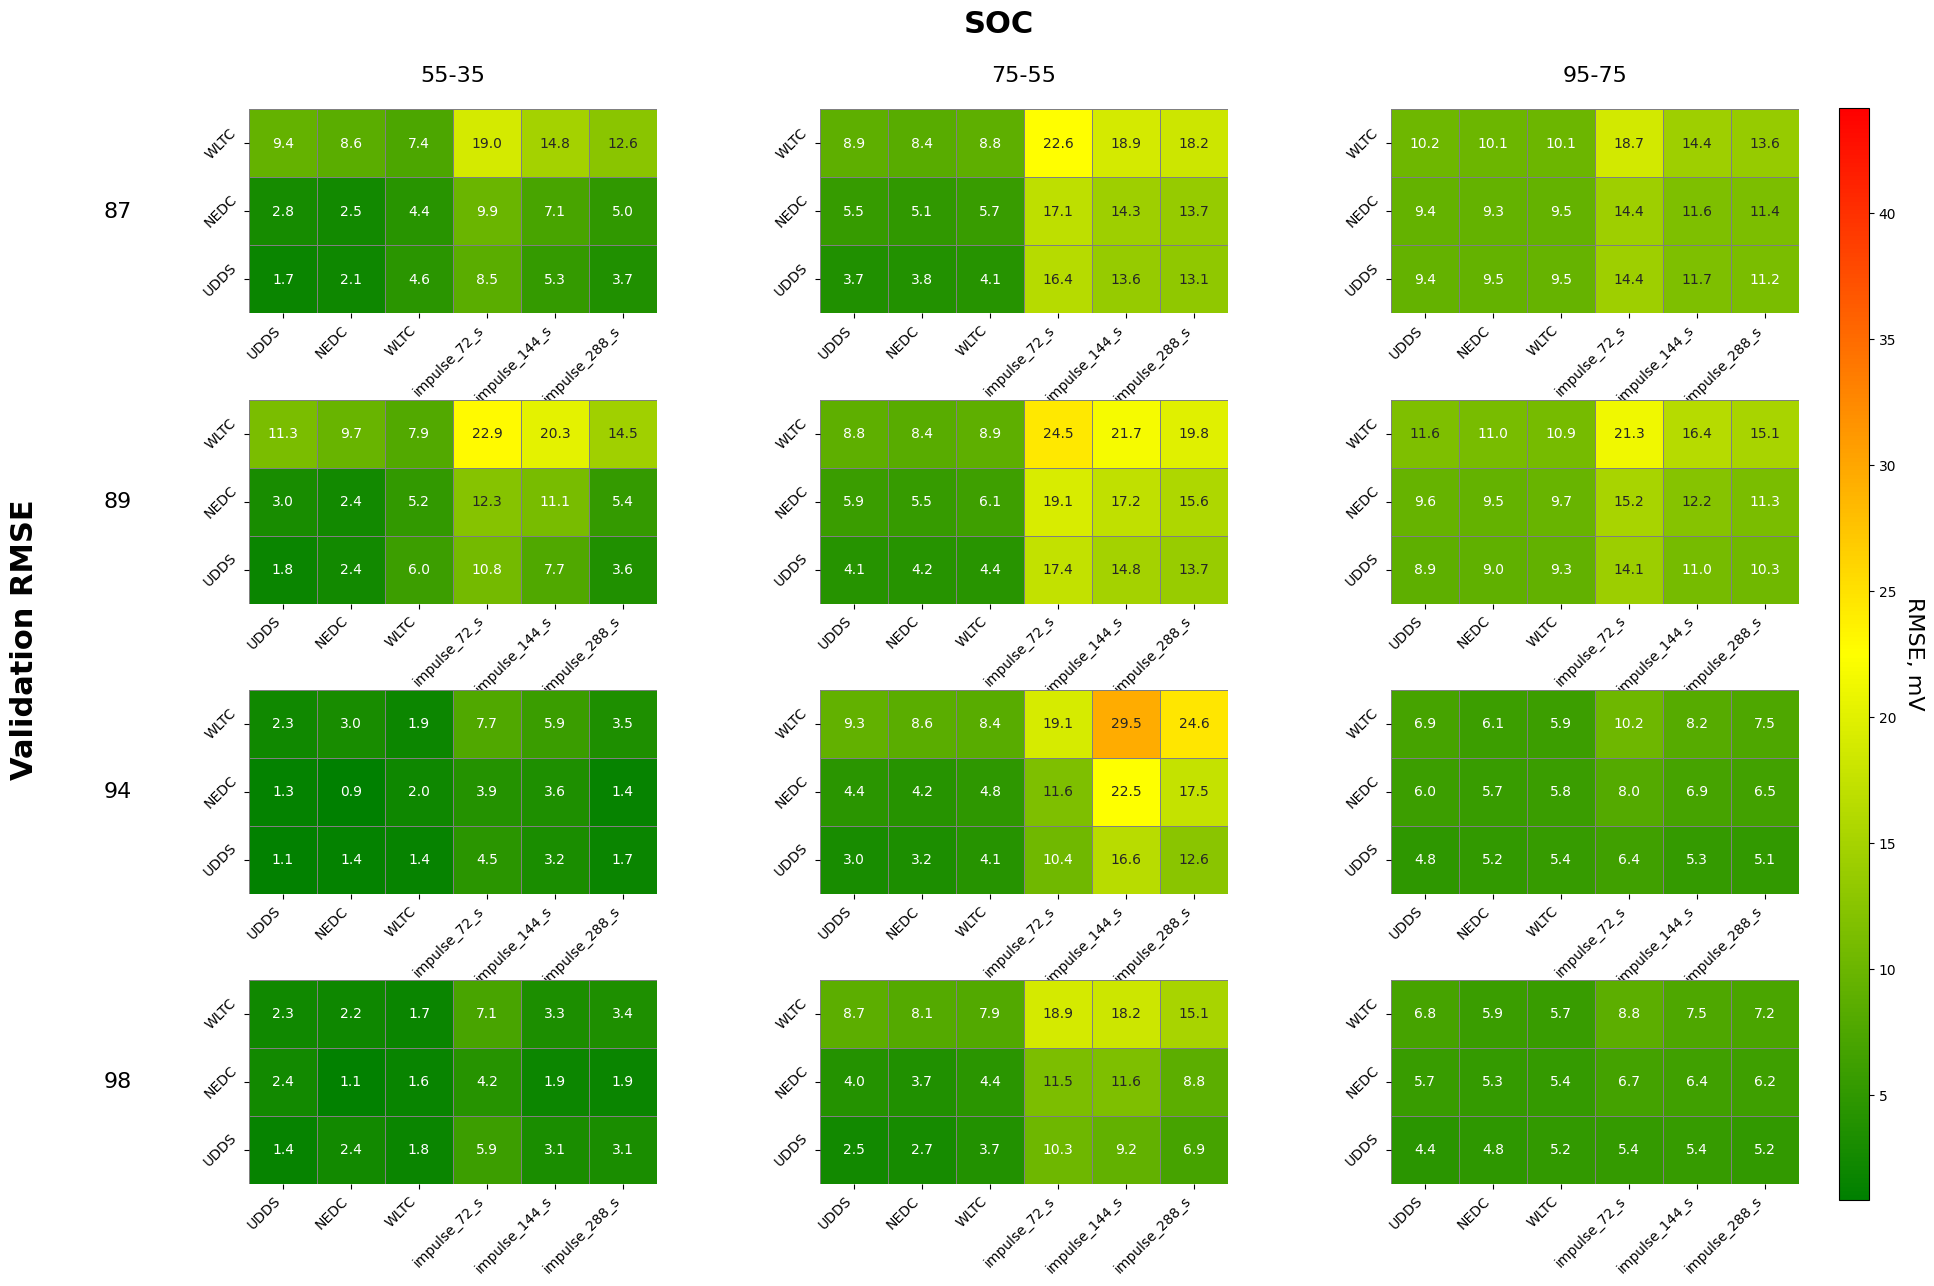

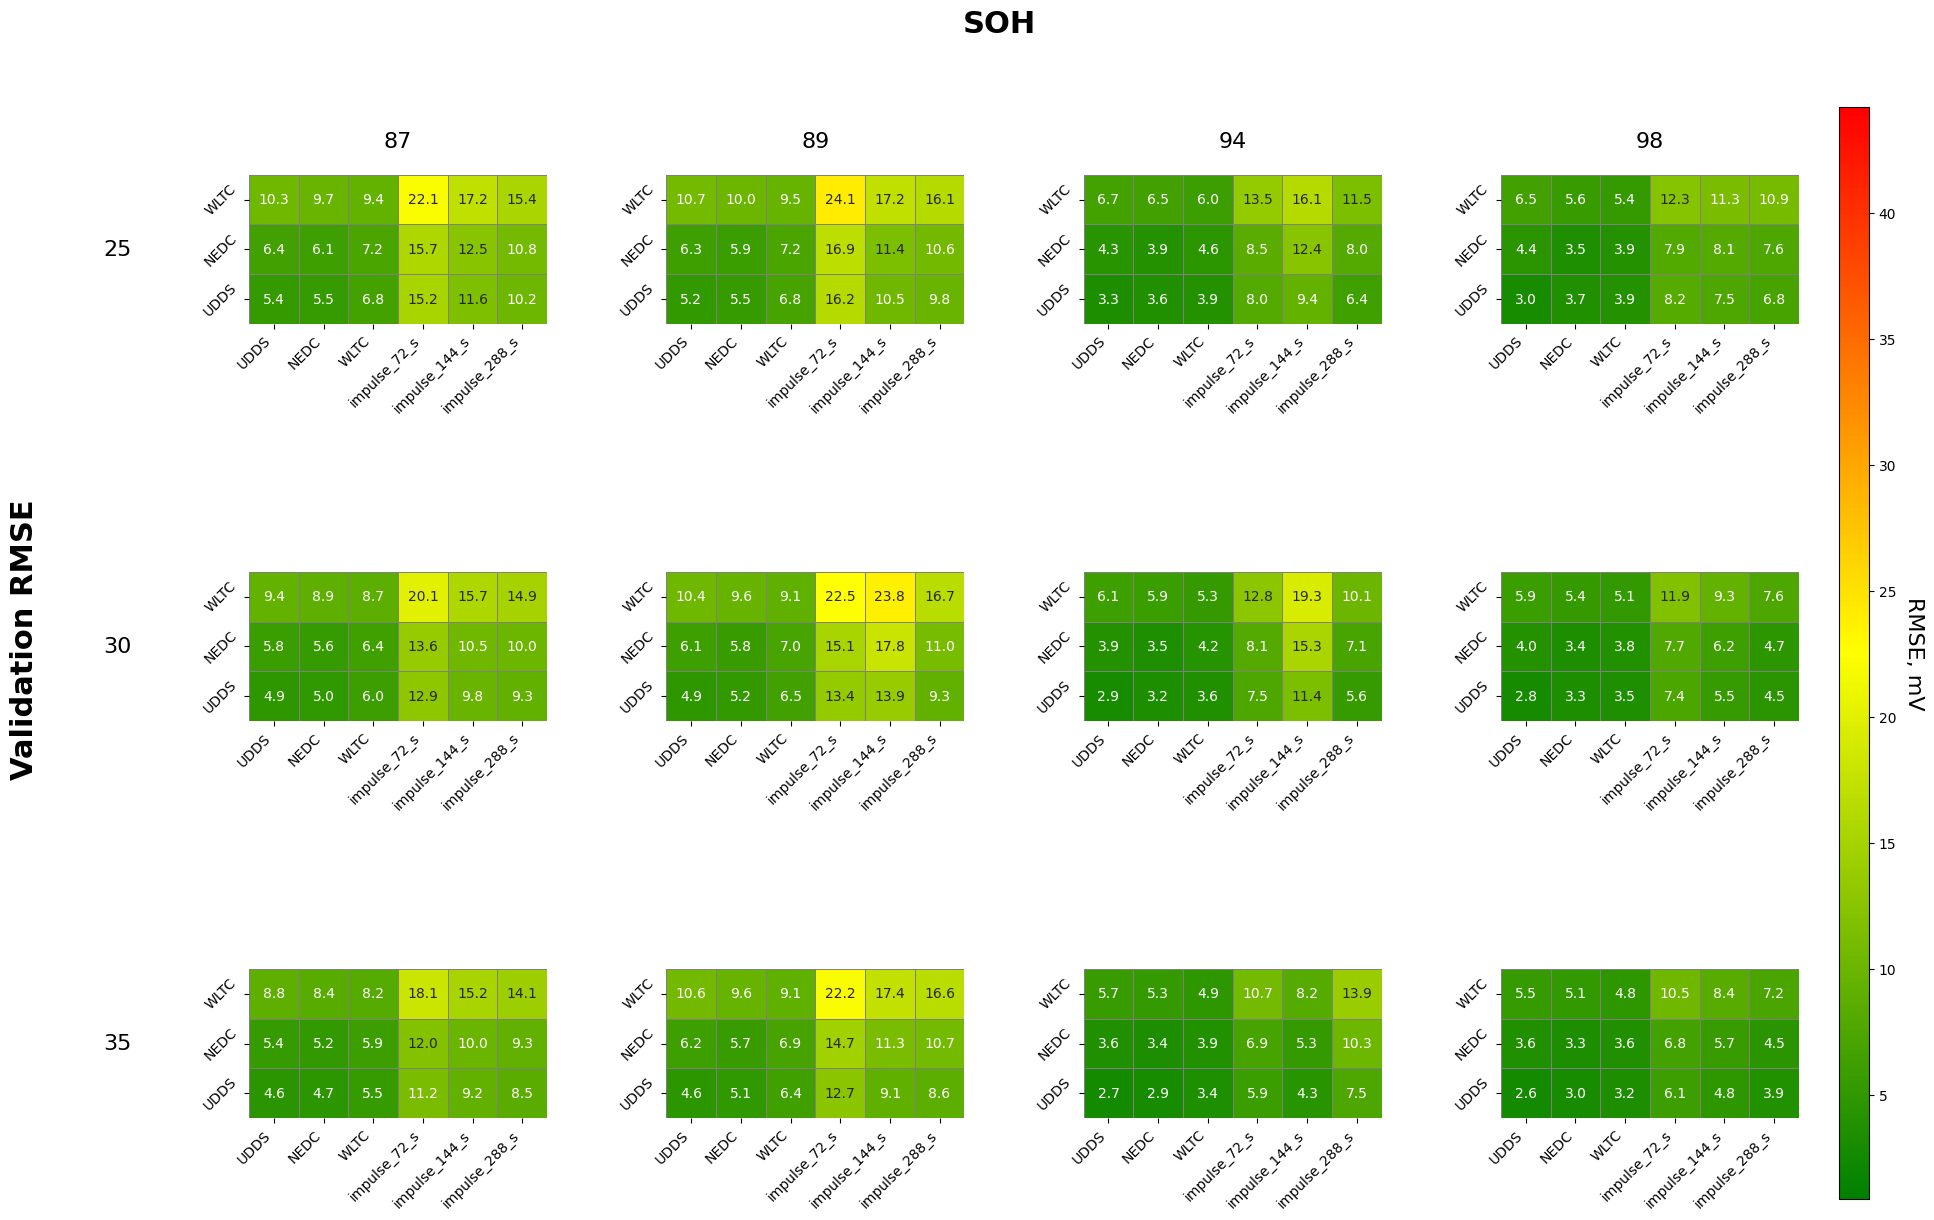

In [11]:
# SOC × T
plot_rmse_heatmap_matrix(
    df_results,
    x_axis="SOC",
    y_axis="T",
    vmin=vmin_global,
    vmax=vmax_global,
    save_path=current_dir.parent / "validation" / "rmse_heatmap_SOC_T.png"
)

# SOC × SOH (усреднение по T)
plot_rmse_heatmap_matrix(
    df_results,
    x_axis="SOC",
    y_axis="SOH",
    vmin=vmin_global,
    vmax=vmax_global,
    save_path=current_dir.parent / "validation" / "rmse_heatmap_SOC_SOH.png"
)

# SOH × T (усреднение по SOC)
plot_rmse_heatmap_matrix(
    df_results,
    x_axis="SOH",
    y_axis="T",
    vmin=vmin_global,
    vmax=vmax_global,
    save_path=current_dir.parent / "validation" / "rmse_heatmap_SOH_T.png"
)


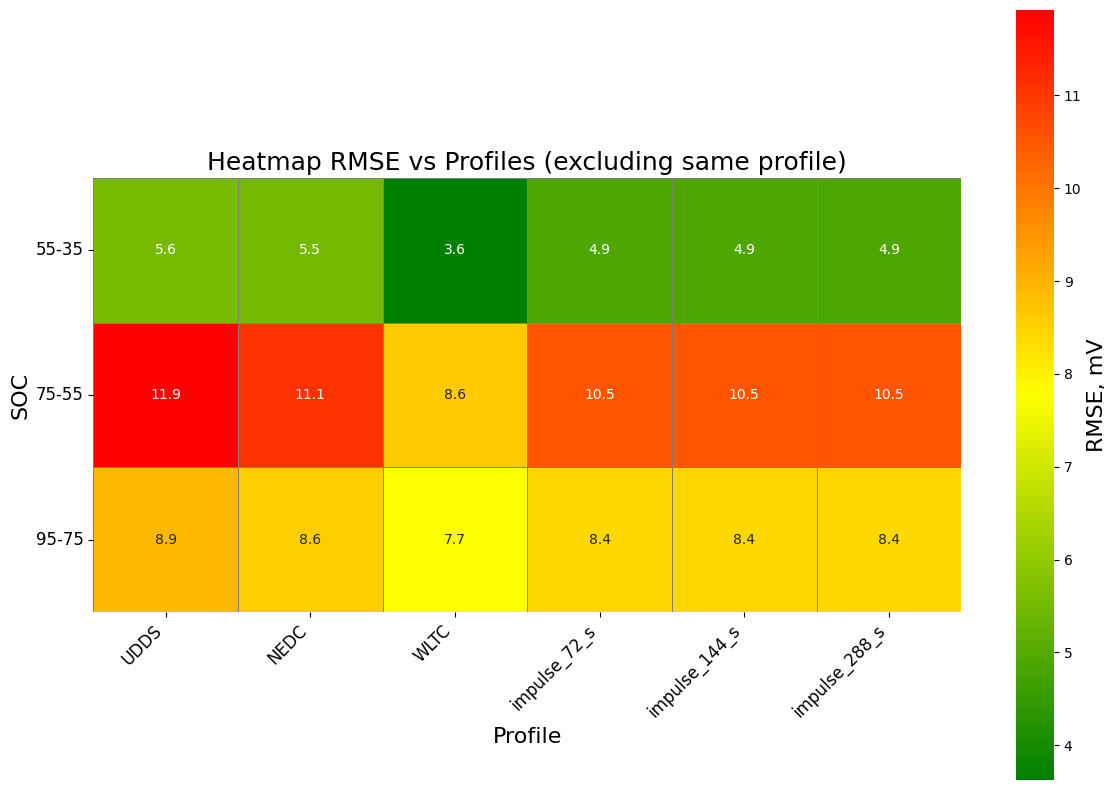

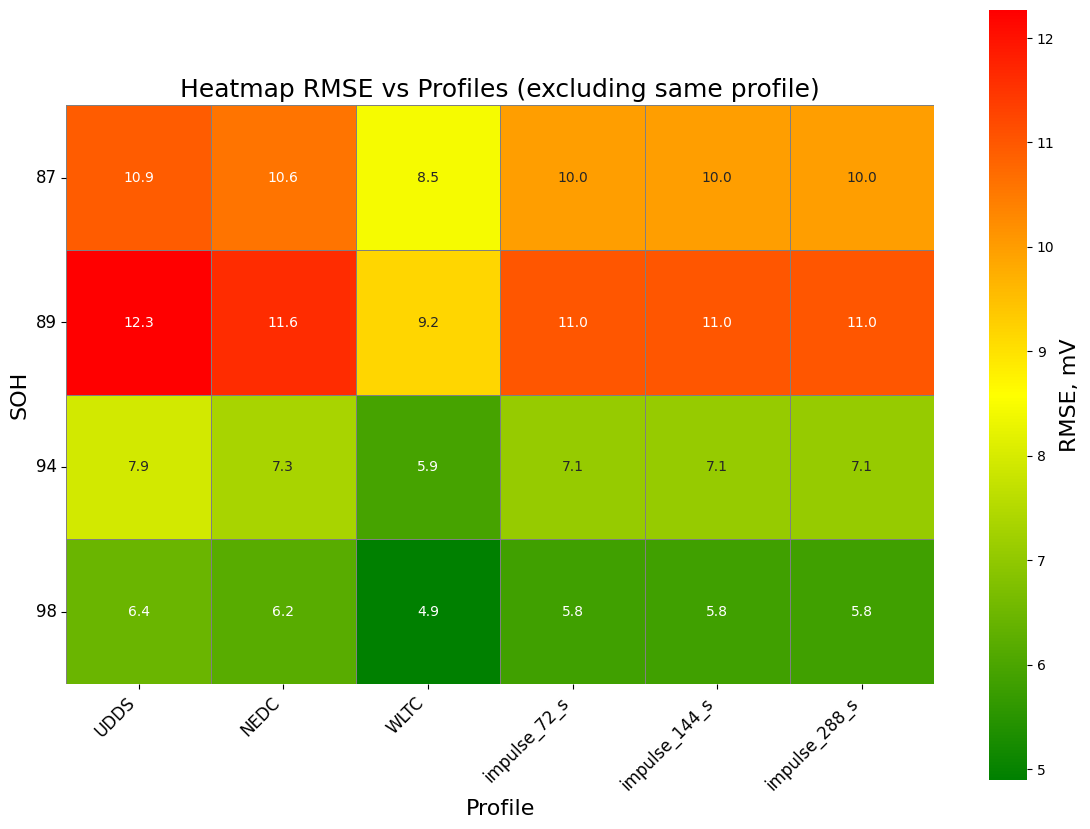

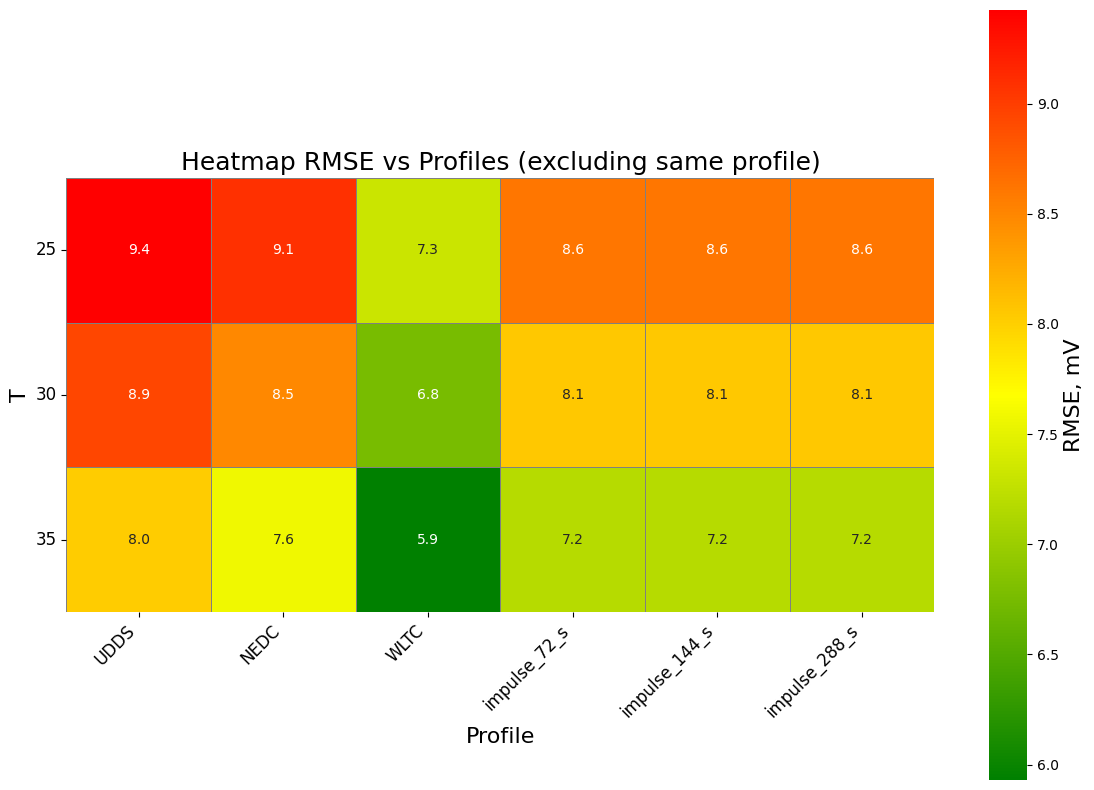

In [12]:
# Пример использования функции

# Список RMSE столбцов в вашем DataFrame
rmse_columns = ["UDDS_rmse", "NEDC_rmse", "WLTC_rmse"]

# Порядок профилей на оси X
profile_order = ["UDDS", "NEDC", "WLTC", "impulse_72_s", "impulse_144_s", "impulse_288_s"]

# Построить heatmap RMSE по SOC (ось Y) и профилям (ось X)
plot_rmse_heatmap_profiles(
    df_results=df_results,
    y_axis="SOC",              # По оси Y — SOC
    rmse_cols=rmse_columns,    # RMSE столбцы
    profile_order=profile_order,
    scale_factor=1000,         # Для перевода в мВ
    figsize=(14,10),
    ticklabel_fontsize=12,
    axislabel_fontsize=16,
    title_fontsize=18,
    save_path=None             # Можно указать путь для сохранения картинки
)

# Построить heatmap RMSE по SOC (ось Y) и профилям (ось X)
plot_rmse_heatmap_profiles(
    df_results=df_results,
    y_axis="SOH",              # По оси Y — SOC
    rmse_cols=rmse_columns,    # RMSE столбцы
    profile_order=profile_order,
    scale_factor=1000,         # Для перевода в мВ
    figsize=(14,10),
    ticklabel_fontsize=12,
    axislabel_fontsize=16,
    title_fontsize=18,
    save_path=None             # Можно указать путь для сохранения картинки
)

# Построить heatmap RMSE по SOC (ось Y) и профилям (ось X)
plot_rmse_heatmap_profiles(
    df_results=df_results,
    y_axis="T",              # По оси Y — SOC
    rmse_cols=rmse_columns,    # RMSE столбцы
    profile_order=profile_order,
    scale_factor=1000,         # Для перевода в мВ
    figsize=(14,10),
    ticklabel_fontsize=12,
    axislabel_fontsize=16,
    title_fontsize=18,
    save_path=None             # Можно указать путь для сохранения картинки
)

C:\Users\lexa-\AppData\Local\Temp\ipykernel_20576\1170187209.py:67: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=45, ha="right")


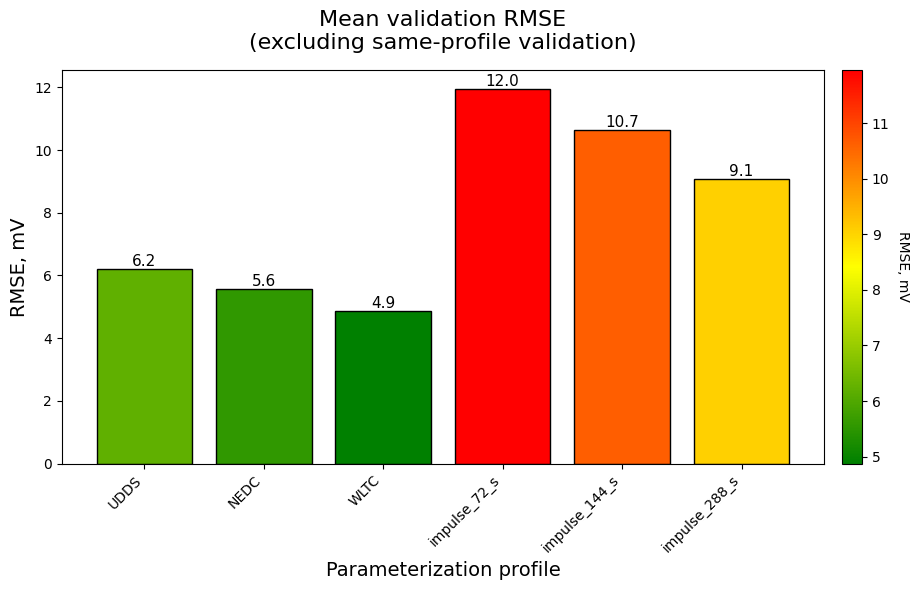

In [13]:
rmse_cols = ["UDDS_rmse", "NEDC_rmse", "WLTC_rmse"]

profile_order = [
    "UDDS",
    "NEDC",
    "WLTC",
    "impulse_72_s",
    "impulse_144_s",
    "impulse_288_s"
]

plot_rmse_profile_histogram(
    df_results,
    rmse_cols=rmse_cols,
    profile_order=profile_order
)


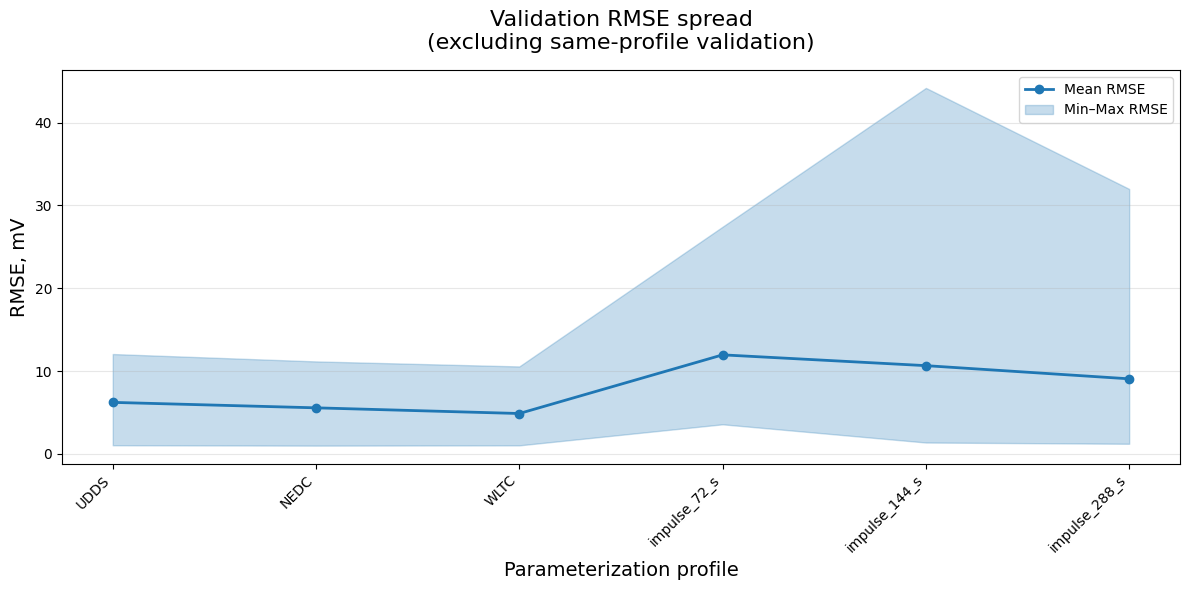

In [14]:
rmse_cols = ["UDDS_rmse", "NEDC_rmse", "WLTC_rmse"]

profile_order = [
    "UDDS",
    "NEDC",
    "WLTC",
    "impulse_72_s",
    "impulse_144_s",
    "impulse_288_s"
]

plot_rmse_profile_with_spread(
    df_results,
    rmse_cols=rmse_cols,
    profile_order=profile_order
)


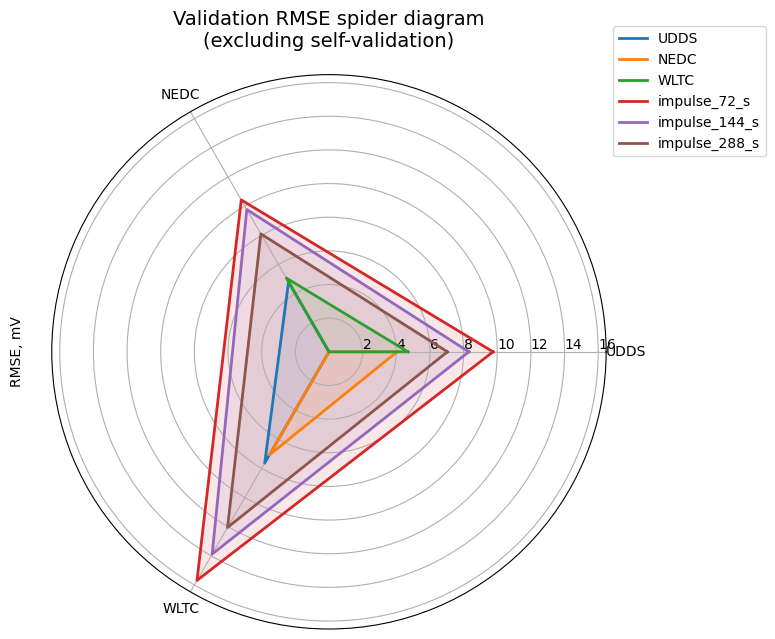

In [16]:
rmse_cols = ["UDDS_rmse", "NEDC_rmse", "WLTC_rmse"]

profile_order = [
    "UDDS",
    "NEDC",
    "WLTC",
    "impulse_72_s",
    "impulse_144_s",
    "impulse_288_s"
]

plot_rmse_spider(
    df_results,
    rmse_cols=rmse_cols,
    profile_order=profile_order,
    normalize=False
)
